## EDA With Red Wine Data

Data Set Information:

The two datasets are related to red and white variants of the Portuguese "Vinho Verde" wine.  Due to privacy and logistic issues, only physicochemical (inputs) and sensory (the output) variables are available (e.g. there is no data about grape types, wine brand, wine selling price, etc.).

These datasets can be viewed as classification or regression tasks. The classes are ordered and not balanced (e.g. there are many more normal wines than excellent or poor ones). Outlier detection algorithms could be used to detect the few excellent or poor wines. Also, we are not sure if all input variables are relevant. So it could be interesting to test feature selection methods.


Attribute Information:

Input variables (based on physicochemical tests):
- 1 - fixed acidity
- 2 - volatile acidity
- 3 - citric acid
- 4 - residual sugar
- 5 - chlorides
- 6 - free sulfur dioxide
- 7 - total sulfur dioxide
- 8 - density
- 9 - pH
- 10 - sulphates
- 11 - alcohol

Output variable (based on sensory data):
- 12 - quality (score between 0 and 10)

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df=pd.read_csv("./Datasets/wine_quality/winequality-red.csv",sep=";")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [28]:
print(df.info())
print(df.describe())  ## Descriptive Summary of the DataSet
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.00000

In [57]:
df["quality"].value_counts()

quality
5    577
6    535
7    167
4     53
8     17
3     10
Name: count, dtype: int64

In [24]:
df.isnull().sum().sum()

np.int64(0)

In [33]:
## Checking For the Duplicate Values
df.duplicated().sum()
print(df[df.duplicated()])

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
4               7.4             0.700         0.00            1.90      0.076   
11              7.5             0.500         0.36            6.10      0.071   
27              7.9             0.430         0.21            1.60      0.106   
40              7.3             0.450         0.36            5.90      0.074   
65              7.2             0.725         0.05            4.65      0.086   
...             ...               ...          ...             ...        ...   
1563            7.2             0.695         0.13            2.00      0.076   
1564            7.2             0.695         0.13            2.00      0.076   
1567            7.2             0.695         0.13            2.00      0.076   
1581            6.2             0.560         0.09            1.70      0.053   
1596            6.3             0.510         0.13            2.30      0.076   

      free sulfur dioxide  

In [38]:
## Droping the Duplicate Values
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

0


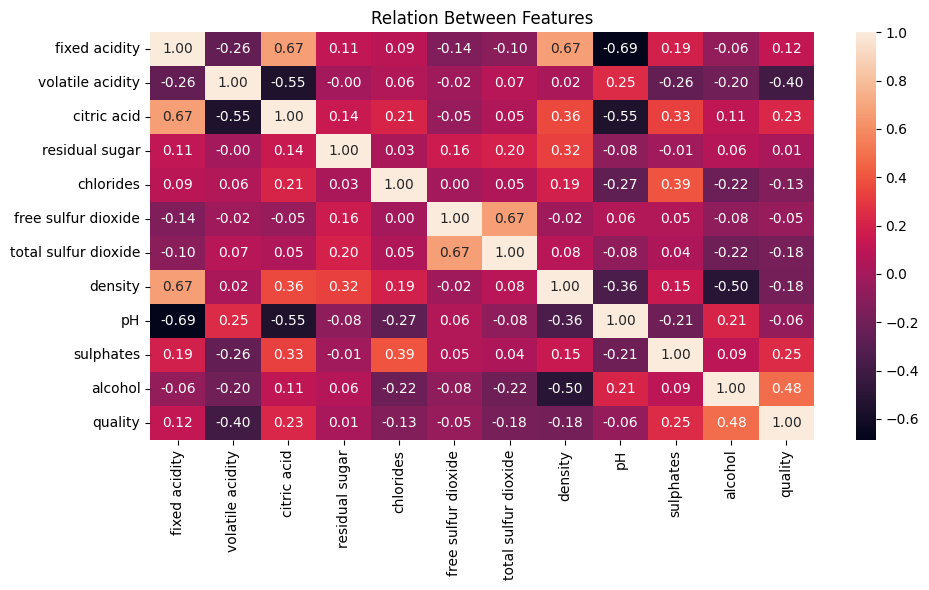

In [55]:
## Correlation
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,fmt=".2f")
plt.title("Relation Between Features")
plt.tight_layout()
plt.show()

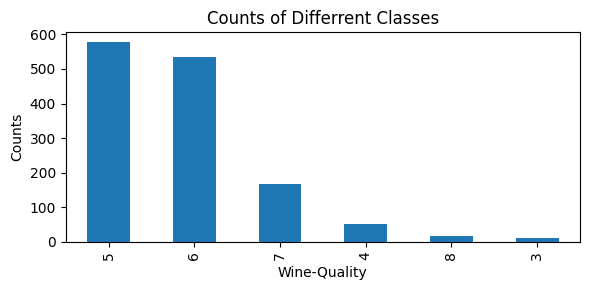

In [74]:
## Visualiztion
plt.figure(figsize=(6,3))
df["quality"].value_counts().plot(kind='bar')  ## Imbalanced Dataset
plt.title("Counts of Differrent Classes")
plt.xlabel("Wine-Quality")
plt.ylabel("Counts")
plt.tight_layout()
plt.show()

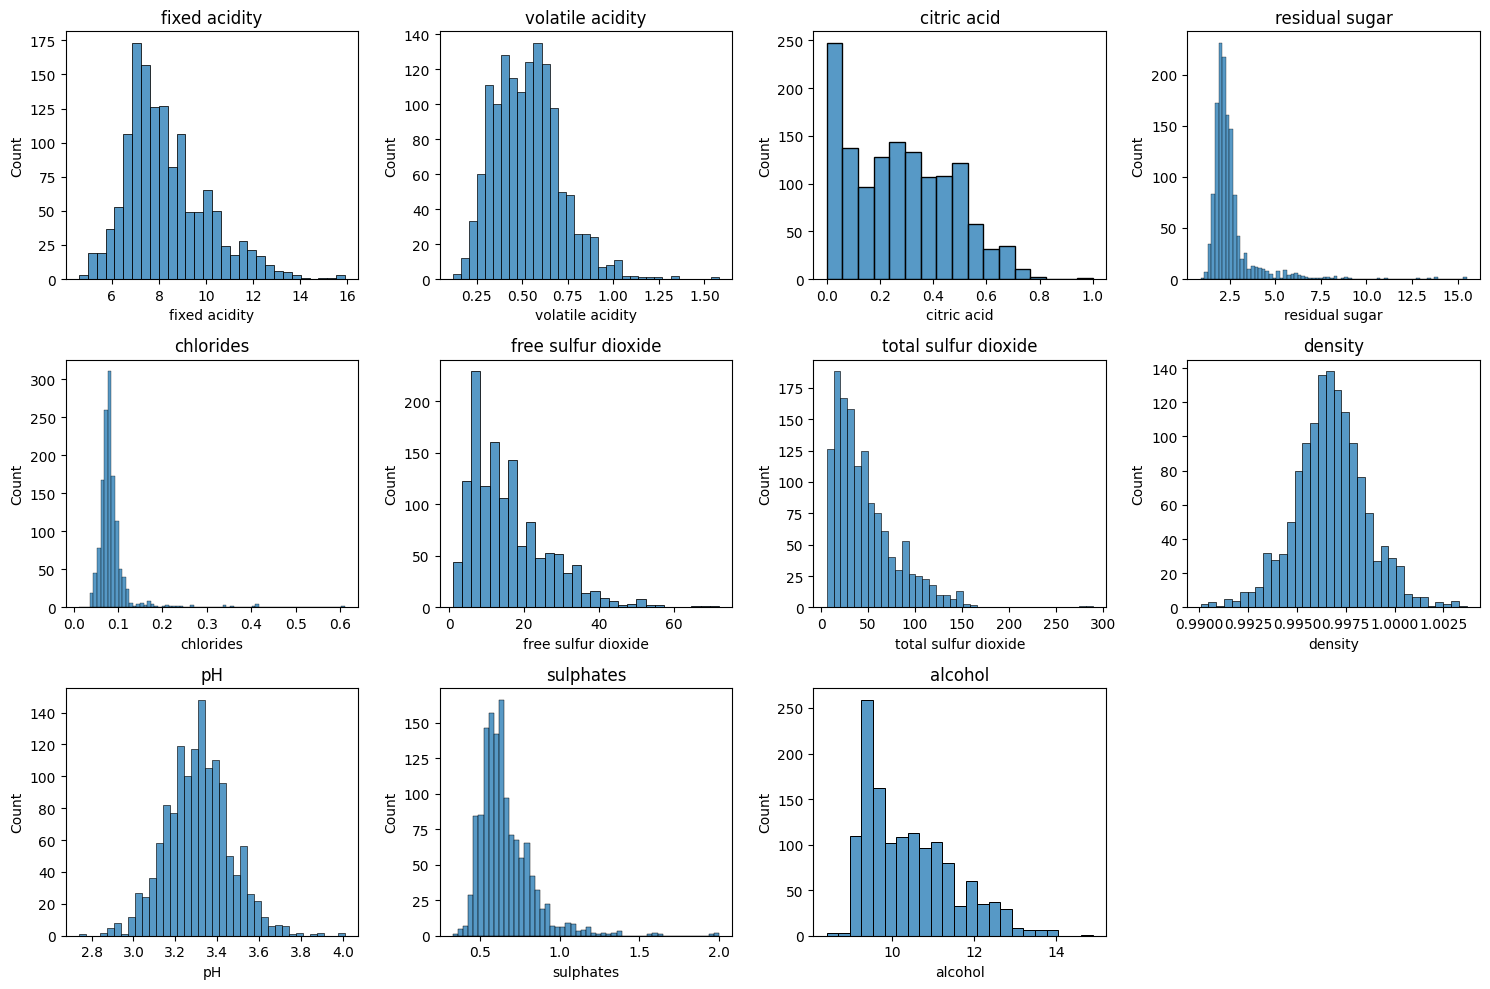

In [75]:
cols = df.columns[:11]

fig, ax = plt.subplots(3, 4, figsize=(15,10))

ax = ax.flatten()  # convert 2D → 1D for easy loop

for i, col in enumerate(cols):
    sns.histplot(df[col], ax=ax[i])
    ax[i].set_title(col)

# Remove extra plot (12th empty)
fig.delaxes(ax[-1])

plt.tight_layout()
plt.show()

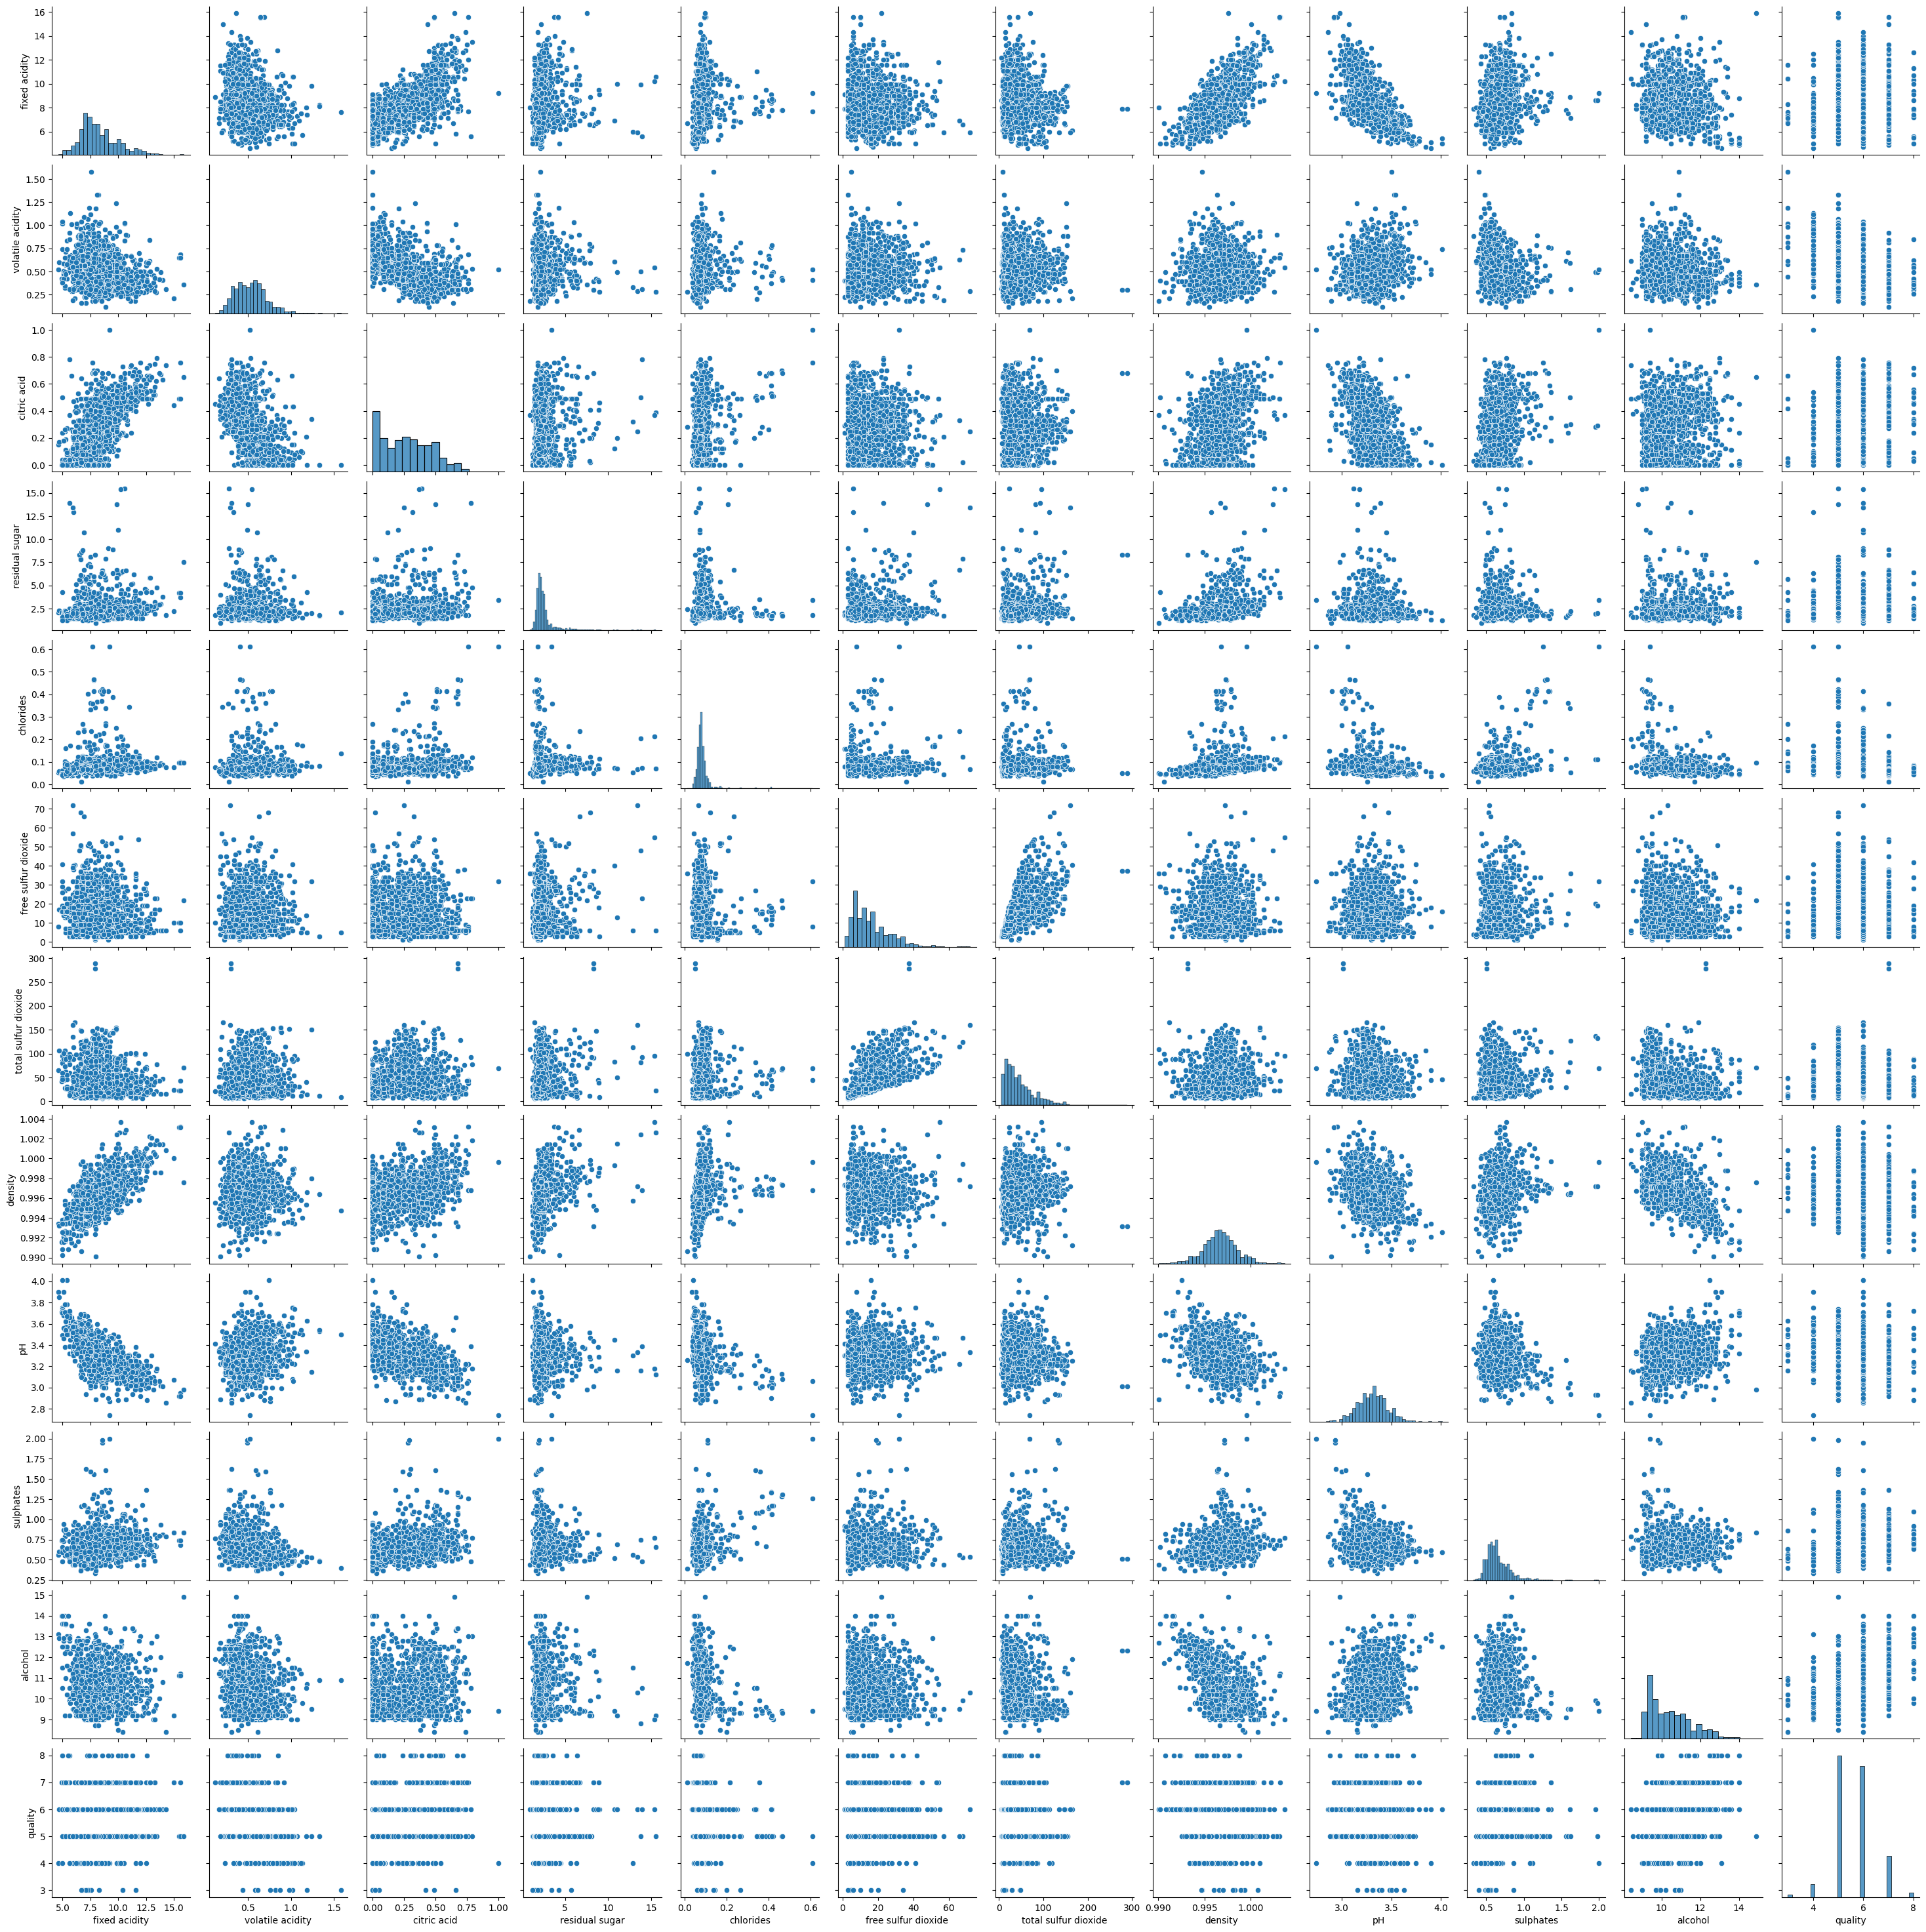

In [78]:
## Univariate,Bivariate,Multivariate Analysis
sns.pairplot(df)

C:\Users\visha\AppData\Local\Temp\ipykernel_16652\2039044744.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x="quality",y="alcohol",data=df,kind='box',palette='Set1')


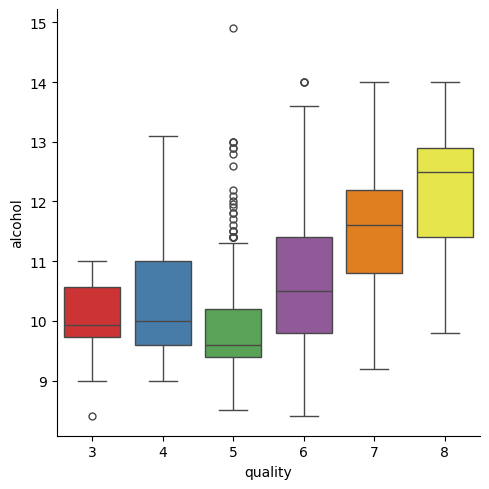

In [100]:
## Categorical Plot
sns.catplot(x="quality",y="alcohol",data=df,kind='box',palette='Set1')

C:\Users\visha\AppData\Local\Temp\ipykernel_16652\2750164337.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x="quality",y="volatile acidity",data=df,kind='box',palette='Set1')


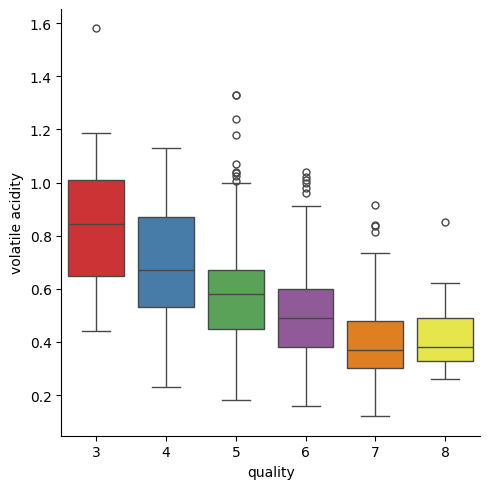

In [113]:
sns.catplot(x="quality",y="volatile acidity",data=df,kind='box',palette='Set1')

C:\Users\visha\AppData\Local\Temp\ipykernel_16652\3552711597.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x="quality",y="sulphates",data=df,kind='box',palette='Set1')


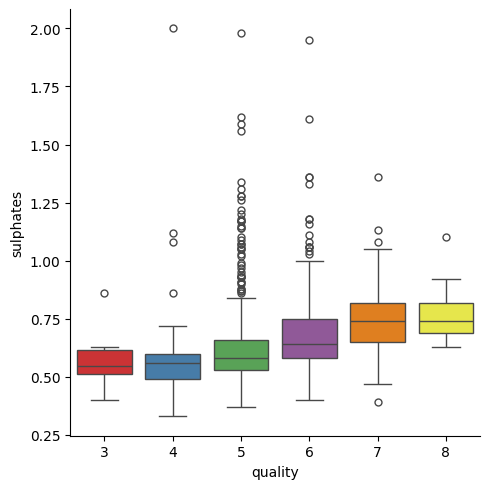

In [112]:
sns.catplot(x="quality",y="sulphates",data=df,kind='box',palette='Set1')

[]

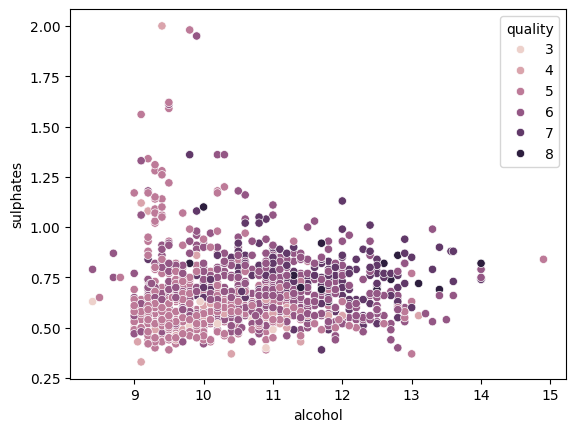

In [111]:
sns.scatterplot(x='alcohol',y='sulphates',hue='quality',data=df)
plt.plot()